In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [19]:
original_data = pd.read_csv('./data/spam.csv')

In [20]:
print(original_data.head())
print(original_data.shape)
print(original_data.info())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [21]:
data = original_data.drop_duplicates()
print(data.shape)

(5157, 2)


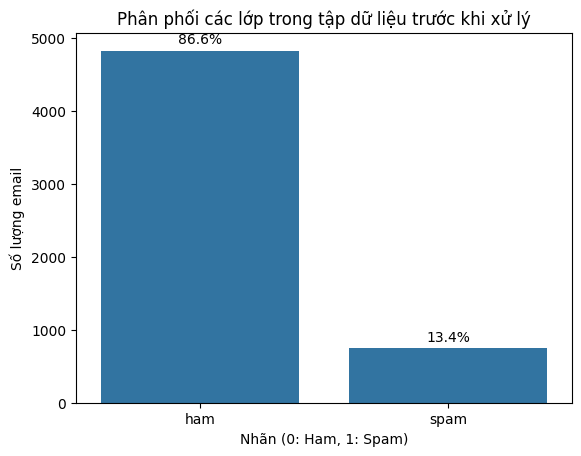

In [22]:
ax = sns.countplot(x='Category', data=original_data)
# 2. Tính toán và chèn phần trăm lên đầu các cột
# Chạy qua từng cột (container) của biểu đồ để tính % dựa trên tổng số dòng
for container in ax.containers:
    # Lấy số lượng của từng cột chia cho tổng số dữ liệu để ra tỷ lệ
    labels = [f'{v.get_height() / len(original_data) * 100:.1f}%' for v in container]
    # Ghi chữ lên đầu cột
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 3. Các thông tin bổ sung
plt.title('Phân phối các lớp trong tập dữ liệu trước khi xử lý')
plt.xlabel('Nhãn (0: Ham, 1: Spam)')
plt.ylabel('Số lượng email')
plt.show()

In [16]:
# data['label'] = data['Category'].replace({'ham': 0, 'spam': 1})
# print(data.head())

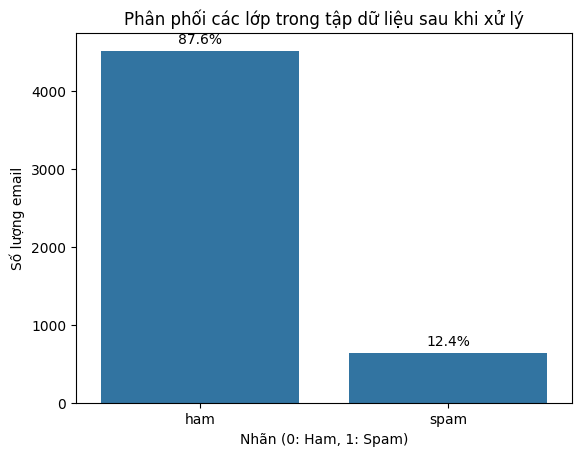

In [ ]:
ax = sns.countplot(x='Category', data=data)
# 2. Tính toán và chèn phần trăm lên đầu các cột
# Chạy qua từng cột (container) của biểu đồ để tính % dựa trên tổng số dòng
for container in ax.containers:
    # Lấy số lượng của từng cột chia cho tổng số dữ liệu để ra tỷ lệ
    labels = [f'{v.get_height() / len(data) * 100:.1f}%' for v in container]
    # Ghi chữ lên đầu cột
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 3. Các thông tin bổ sung
plt.title('Phân phối các lớp trong tập dữ liệu sau khi xử lý')
plt.xlabel('Nhãn (0: Ham, 1: Spam)')
plt.ylabel('Số lượng email')
plt.show()

In [25]:
vectorizer = TfidfVectorizer()
message_tfidf = vectorizer.fit_transform(message)
smote = SMOTE()
message_smote, category_smote = smote.fit_resample(message_tfidf, category)

NameError: name 'message' is not defined

In [25]:
# Chia train/test set, 80% dữ liệu để train, 20% để test
message_train, message_test, category_train, category_test = train_test_split(message, category, test_size=0.2, random_state=3)